<a href="https://colab.research.google.com/github/kavivarshini25/Kavivarshini_INFO5731_FALL2025/blob/main/Kandhasami_Kavivarshini_Assignment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **INFO5731 Assignment 3**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).


**Total points**: 100

**Deadline**: See Canvas

**Late Submission will have a penalty of 10% reduction for each day after the deadline.**


## Question 1 (30 points)

**Understand N-gram**

Write a python program to conduct N-gram analysis based on the dataset in your assignment two. You need to write codes from **scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (N=3) and (N=2).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula  count(w2 w1) / count(w2). For example, count(really like) / count(really) = 1 / 3 = 0.33.

(3) Extract all the noun phrases and calculate the relative
probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula  frequency (noun phrase) / max frequency (noun phrase) on the whole dataset.

Print out the result in a table with column name the all the noun phrases and row name as all the 100 reviews (abstracts, or tweets).

In [2]:
import pandas as pd
import re
from collections import Counter
from tabulate import tabulate


myfile = pd.read_csv("/content/Final_List_of_narrs_cleaned.csv")
print("Columns:", myfile.columns.tolist())


texts = myfile['Cleaned Bio'].dropna().tolist()


def simple_tokenizer(text):

    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    return [t for t in tokens if t.strip()]

tokenized_texts = [simple_tokenizer(text.lower()) for text in texts]

def generate_ngrams(tokens, n):
    ngrams = []
    for i in range(len(tokens) - n + 1):
        ngram = tuple(tokens[i:i + n])
        ngrams.append(ngram)
    return ngrams

bgrm_frq = Counter()
trgrm_frq = Counter()

for tokens in tokenized_texts:
    bgrm_frq.update(generate_ngrams(tokens, 2))
    trgrm_frq.update(generate_ngrams(tokens, 3))

print("\nTop 10 Bigrams:")
for bg, c in bgrm_frq.most_common(10):
    print(bg, ":", c)

print("\nTop 10 Trigrams:")
for tg, c in trgrm_frq.most_common(10):
    print(tg, ":", c)


pd.DataFrame(bgrm_frq.items(), columns=['Bigram', 'Count']).to_csv("Bigram_Counts.csv", index=False)
pd.DataFrame(trgrm_frq.items(), columns=['Trigram', 'Count']).to_csv("Trigram_Counts.csv", index=False)


word_counts = Counter([w for tokens in tokenized_texts for w in tokens])
bigram_prob = {}

for (w1, w2), count in bgrm_frq.items():
    if word_counts[w1] > 0:
        bigram_prob[(w1, w2)] = count / word_counts[w1]

print("\nSample Bigram Probabilities:")
for pair, prob in list(bigram_prob.items())[:10]:
    print(pair, ":", round(prob, 4))

pd.DataFrame(
    [(w1, w2, p) for (w1, w2), p in bigram_prob.items()],
    columns=['Word1', 'Word2', 'Probability']
).to_csv("Bigram_Probabilities.csv", index=False)


print("\n Files saved successfully:")
print(" - Bigram_Counts.csv")
print(" - Trigram_Counts.csv")
print(" - Bigram_Probabilities.csv")
print(" - Noun_Phrase_Relative_Probabilities.csv")









Columns: ['narr Name', 'Bio', 'Interview Title', 'Date & Location', 'Densho ID', 'Cleaned Bio']

Top 10 Bigrams:
('concentr', 'camp') : 808
('world', 'war') : 650
('war', 'ii') : 650
('male', 'born') : 499
('assembl', 'center') : 424
('nisei', 'male') : 398
('femal', 'born') : 393
('nisei', 'femal') : 301
('lo', 'angel') : 295
('ii', 'remov') : 289

Top 10 Trigrams:
('world', 'war', 'ii') : 650
('nisei', 'male', 'born') : 385
('nisei', 'femal', 'born') : 292
('war', 'ii', 'remov') : 289
('concentr', 'camp', 'california') : 265
('assembl', 'center', 'california') : 226
('bomb', 'pearl', 'harbor') : 202
('minidoka', 'concentr', 'camp') : 188
('concentr', 'camp', 'idaho') : 180
('manzanar', 'concentr', 'camp') : 150

Sample Bigram Probabilities:
('nisei', 'femal') : 0.3966
('femal', 'born') : 0.9447
('born', 'may') : 0.0809
('may', 'selleck') : 0.012
('selleck', 'washington') : 0.6
('washington', 'spent') : 0.0491
('spent', 'much') : 0.0328
('much', 'childhood') : 0.1818
('childhood', 'be

In [3]:
import re
import pandas as pd
from collections import defaultdict, Counter

stp_wrd = {
    'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'is', 'it', 'you', 'he', 'she', 'we', 'they',
    'this', 'that', 'these', 'those', 'my', 'your', 'his', 'her', 'its', 'their', 'our', 'i', 'of', 'to', 'for',
    'on', 'in', 'at', 'with', 'by', 'from', 'about', 'as', 'than', 'be', 'been', 'being', 'have', 'has', 'had',
    'having', 'do', 'does', 'did', 'doing', 'if', 'will', 'just', 'don', 'nor', 'not', 'only', 'own', 'same',
    'so', 'too', 'very', 's', 't', 'can', 'should', 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren',
    'couldn', 'didn', 'doesn', 'hadn', 'hasn', 'haven', 'isn', 'ma', 'mightn', 'mustn', 'needn', 'shan',
    'shouldn', 'wasn', 'weren', 'won', 'wouldn'
}

def is_noun(word):
    """Heuristic to identify possible nouns (lowercase friendly)."""
    word = word.strip(",.!?;:()[]{}").lower()
    if word in stp_wrd or len(word) <= 2:
        return False

    noun_sufx = ['ness', 'ion', 'ment', 'er', 'or', 'ism', 'ant', 'age', 'ity', 'ist']
    if any(word.endswith(suffix) for suffix in noun_sufx):
        return True

    # Common nouns in bios
    cmn_noun = {'camp', 'center', 'school', 'church', 'temple', 'university',
                    'assembly', 'california', 'washington', 'oregon', 'idaho', 'harbor',
                    'japan', 'internment', 'war', 'project'}
    if word in cmn_noun:
        return True

    return False


def is_determiner(word):

    detrmners = {'the', 'a', 'an', 'this', 'that', 'these', 'those',
                   'my', 'your', 'his', 'her', 'its', 'their', 'our'}
    return word.lower() in detrmners


def extrct_com_nun_phrse(text):

    words = text.split()
    noun_phrse = []
    phrase = []

    for word in words:
        word = word.strip(",.!?;:")
        lw = word.lower()

        if is_determiner(lw) and not phrase:
            phrase = [word]
        elif is_noun(lw):
            phrase.append(word)
        else:
            if phrase and len(phrase) > 1 and is_noun(phrase[-1].lower()):
                noun_phrse.append(" ".join(phrase))
            phrase = []


    if phrase and len(phrase) > 1 and is_noun(phrase[-1].lower()):
        noun_phrse.append(" ".join(phrase))

    return noun_phrse


def compute_global_noun_phrase_frequencies(narrators):
    global_counts = Counter()
    narrator_phrases = defaultdict(list)

    for i, text in enumerate(narrators):
        noun_phrse = extrct_com_nun_phrse(text)
        global_counts.update(noun_phrse)
        narrator_phrases[i] = noun_phrse

    return global_counts, narrator_phrases


def compute_relative_probabilities(narrator_phrases):
    fnlrslt = []
    for narrator_id, noun_phrse in narrator_phrases.items():
        phrase_counts = Counter(noun_phrse)
        total = sum(phrase_counts.values())
        if total == 0:
            continue
        relative_probs = {phrase: count / total for phrase, count in phrase_counts.items()}
        fnlrslt.append({"narrator": narrator_id + 1, "relative_probabilities": relative_probs})
    return fnlrslt


def display_table(data, limit=50):

    headers = ["Narrator", "Noun Phrase", "Relative Probability"]
    col_widths = [10, 40, 20]
    header_row = " | ".join([f"{h:<{w}}" for h, w in zip(headers, col_widths)])
    print(header_row)
    print("-" * len(header_row))

    for row in data[:limit]:
        narrator, phrase, prob = row
        formatted_row = [
            f"{narrator:<{col_widths[0]}}",
            f"{phrase:<{col_widths[1]}}",
            f"{prob:<{col_widths[2]}}"
        ]
        print(" | ".join(formatted_row))



flpth = "/content/Final_List_of_narrs_cleaned.csv"
myfile = pd.read_csv(flpth)

if "Cleaned Bio" in myfile.columns:
    narrators = myfile["Cleaned Bio"].dropna().tolist()
else:
    raise ValueError("Error: 'Cleaned Bio' column not found in file.")


global_counts, narrator_phrases = compute_global_noun_phrase_frequencies(narrators)
fnlrslt = compute_relative_probabilities(narrator_phrases)


my_tbledta = []
for result in fnlrslt:
    narrator = result["narrator"]
    rel_probs = result["relative_probabilities"]
    for phrase, prob in rel_probs.items():
        my_tbledta.append([narrator, phrase, f"{prob:.2f}"])


display_table(my_tbledta)


Narrator   | Noun Phrase                              | Relative Probability
----------------------------------------------------------------------------
1          | oregon father                            | 0.33                
1          | center oregon                            | 0.33                
1          | camp idaho war                           | 0.33                
2          | washington japan                         | 0.25                
2          | center washington                        | 0.25                
2          | camp idaho                               | 0.25                
2          | camp father                              | 0.25                
3          | center washington                        | 0.50                
3          | camp idaho                               | 0.50                
4          | center california                        | 0.50                
4          | camp mother                              | 0.50                

In [4]:
output_df = pd.DataFrame(my_tbledta, columns=["Narrator", "Noun Phrase", "Relative Probability"])
output_file = "/content/Noun_Phrases_Table.csv"
output_df.to_csv(output_file, index=False)

from google.colab import files
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Question 2 (25 points)

**Undersand TF-IDF and Document representation**

Starting from the documents (all the reviews, or abstracts, or tweets) collected for assignment two, write a python program:

(1) To build the documents-terms weights (tf * idf) matrix.

(2) To rank the documents with respect to query (design a query by yourself, for example, "An Outstanding movie with a haunting performance and best character development") by using cosine similarity.

Note: You need to write codes from scratch instead of using any **pre-existing libraries** to do so.

In [5]:

import math
import pandas as pd
from collections import Counter


flpth = "/content/Final_List_of_narrs_cleaned.csv"
myfile = pd.read_csv(flpth)


if "Cleaned Bio" in myfile.columns:
    documents = myfile["Cleaned Bio"].dropna().astype(str).tolist()
elif "Bio" in myfile.columns:
    documents = myfile["Bio"].dropna().astype(str).tolist()
else:
    raise ValueError("No 'Cleaned Bio' or 'Bio' column found.")


def tokenize(mytxt):
    mytxt = mytxt.lower()
    mytxt = "".join(ch for ch in mytxt if ch.isalnum() or ch.isspace())
    return mytxt.split()

tokenized_docs = [tokenize(doc) for doc in documents]


def compute_tf(doc_tokens):
    counts = Counter(doc_tokens)
    max_count = max(counts.values()) if counts else 1
    return {term: count / max_count for term, count in counts.items()}

tfs = [compute_tf(doc) for doc in tokenized_docs]


def cmpt_imyfle(all_docs):
    N = len(all_docs)
    all_terms = set(term for doc in all_docs for term in doc)
    imyfile = {}
    for term in all_terms:
        containing_docs = sum(1 for doc in all_docs if term in doc)
        imyfile[term] = math.log((N + 1) / (containing_docs + 1)) + 1
    return imyfile

imyfile = cmpt_imyfle(tokenized_docs)

def compute_tfimyfile(tf, imyfile):
    tfimyfile = {term: tf_val * imyfile.get(term, 0.0) for term, tf_val in tf.items()}
    return tfimyfile

tfimyfile_docs = [compute_tfimyfile(tf, imyfile) for tf in tfs]

frst_ndoc = 7   # First N documents
top_trm = 12  # Top terms per document

print("['Word', 'TF-Imyfile'] (Top terms per document)\n")
for i, doc in enumerate(tfimyfile_docs[:frst_ndoc], start=1):
    print(f"Document {i}:")
    top_terms = sorted(doc.items(), key=lambda x: x[1], reverse=True)[:top_trm]
    for term, val in top_terms:
        print([term, val])
    print()


def cosine_similarity(vec1, vec2):
    all_terms = set(vec1.keys()) | set(vec2.keys())
    dot_product = sum(vec1.get(t, 0.0) * vec2.get(t, 0.0) for t in all_terms)
    mag1 = math.sqrt(sum(v**2 for v in vec1.values()))
    mag2 = math.sqrt(sum(v**2 for v in vec2.values()))
    if mag1 == 0 or mag2 == 0:
        return 0.0
    return dot_product / (mag1 * mag2)


query = "An Outstanding narrator named kavi was born in California and setteled in Washington"
query_tokens = tokenize(query)
query_tf = compute_tf(query_tokens)
query_tfimyfile = compute_tfimyfile(query_tf, imyfile)


similarities = []
for i, doc_vec in enumerate(tfimyfile_docs):
   flsim = cosine_similarity(query_tfimyfile, doc_vec)
   similarities.append((i,flsim))

rnkd_dcs = sorted(similarities, key=lambda x: x[1], reverse=True)


print("\n Top 5 Documents Ranked by Query Similarity \n")
for rank, (index,flsim) in enumerate(rnkd_dcs[:5], start=1):
    print(f"Rank {rank}: Document {index+1} | Similarity = {flsim:.4f}")
    print(f"Text snippet: {documents[index][:400]}...\n")








['Word', 'TF-Imyfile'] (Top terms per document)

Document 1:
['homeless', 3.6102950850498696]
['beaverton', 3.4075625309957873]
['feed', 3.4075625309957873]
['selleck', 3.263721494769897]
['oregon', 3.0695502642010934]
['christian', 2.8055761288328194]
['influenc', 2.757921038930657]
['convers', 2.757921038930657]
['much', 2.714415350435842]
['washington', 2.261248170391034]
['program', 2.112428948272874]
['own', 2.031794874474813]

Document 2:
['seattl', 2.6458791915963564]
['tragic', 2.406863390033246]
['wood', 2.406863390033246]
['element', 2.406863390033246]
['signal', 2.406863390033246]
['aeronaut', 2.406863390033246]
['perish', 2.2717083539971914]
['washington', 2.261248170391034]
['work', 2.1207237422755405]
['temporari', 2.1014331460751947]
['loss', 2.1014331460751947]
['area', 2.084163738585092]

Document 3:
['minnesota', 4.250175704530038]
['rochest', 3.4075625309957873]
['mari', 3.152149719112792]
['seattl', 2.6458791915963564]
['pursu', 2.637340010522213]
['nurs', 2.4590025

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for assignment 2 to build a word embedding model:

(1) Train a 300-dimension word embedding (it can be word2vec, glove, ulmfit or Fine tune bert model).

(2) Visualize the embeddings using PCA or t-SNE in 2D. Create a scatter plot of at least 20 words and show how similar words cluster together.

(3) Calculate the cosine similarity between a few pairs of words to see if the model captures semantic similarity accurately.

Reference: https://machinelearningmastery.com/develop-word-embeddings-python-gensim/

Reference: https://jaketae.github.io/study/word2vec/

In [1]:
!pip install gensim matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine

In [3]:
flpth = "/content/Final_List_of_narrs_cleaned.csv"


myfile = pd.read_csv(flpth)


texts = myfile['Cleaned Bio'].dropna().astype(str).tolist() if 'Cleaned Bio' in myfile.columns else myfile['Bio'].dropna().astype(str).tolist()


def tokenize(mytxt):
    mytxt = mytxt.lower()
    mytxt = "".join(ch for ch in mytxt if ch.isalnum() or ch.isspace())
    return mytxt.split()


toknizd_corps = [tokenize(mytxt) for mytxt in texts]

print(f"Total number of documents: {len(toknizd_corps)}")
print(f"Some example tokens from the first document: {toknizd_corps[0][:20]}")


Total number of documents: 1005
Some example tokens from the first document: ['nisei', 'femal', 'born', 'may', 'selleck', 'washington', 'spent', 'much', 'childhood', 'beaverton', 'oregon', 'father', 'own', 'farm', 'influenc', 'earli', 'age', 'parent', 'convers', 'christian']


In [4]:
embedding_dim = 300

w2v_model = Word2Vec(
    sentences=toknizd_corps,
    vector_size=embedding_dim,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

print("The Word2Vec model is trained!")

The Word2Vec model is trained!


In [5]:

words = list(w2v_model.wv.index_to_key[:30])
print("Some words that are selected for visualization are:", words)


word_vectors = [w2v_model.wv[word] for word in words]

# Convert to NumPy array for t-SNE
word_vectors_array = np.array(word_vectors)

Some words that are selected for visualization are: ['camp', 'california', 'war', 'born', 'concentr', 'nisei', 'world', 'ii', 'famili', 'remov', 'return', 'male', 'washington', 'grew', 'center', 'work', 'assembl', 'femal', 'seattl', 'japanes', 'japan', 'school', 'american', 'father', 'move', 'leav', 'lo', 'parent', 'angel', 'serv']


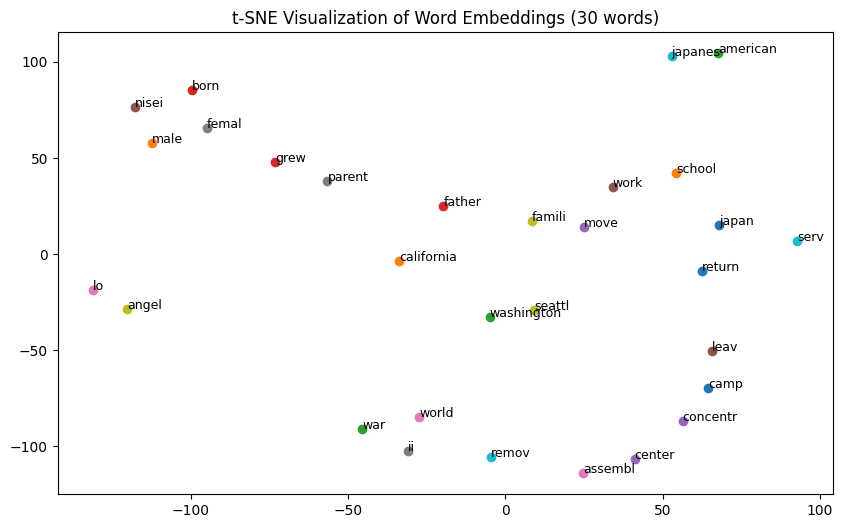

In [6]:
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_result = tsne.fit_transform(word_vectors_array)


plt.figure(figsize=(10,6))
for i, word in enumerate(words):
    plt.scatter(tsne_result[i,0], tsne_result[i,1])
    plt.text(tsne_result[i,0]+0.01, tsne_result[i,1]+0.01, word, fontsize=9)
plt.title("t-SNE Visualization of Word Embeddings (30 words)")
plt.show()

In [7]:

word_pairs = [
    ('nisei', 'sansei'),
    ('california', 'los'),
    ('camp', 'concentr'),
    ('male', 'femal'),
    ('japan', 'japanes'),
    ('born', 'remov'),
    ('father', 'parent'),
    ('school', 'american'),
    ('angel', 'lo'),
    ('war', 'world')
]
from scipy.spatial.distance import cosine

print("\n Cosine Similarities between Word Pairs are:")
for w1, w2 in word_pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        sim = 1 - cosine(w2v_model.wv[w1], w2v_model.wv[w2])
        print(f"'{w1}' ↔ '{w2}': {sim:.4f}")
    else:
        print(f"One of the words '{w1}' or '{w2}' not in vocabulary")



 Cosine Similarities between Word Pairs are:
'nisei' ↔ 'sansei': 0.9860
One of the words 'california' or 'los' not in vocabulary
'camp' ↔ 'concentr': 0.9735
'male' ↔ 'femal': 0.9942
'japan' ↔ 'japanes': 0.2735
'born' ↔ 'remov': 0.7054
'father' ↔ 'parent': 0.9114
'school' ↔ 'american': 0.3014
'angel' ↔ 'lo': 0.9635
'war' ↔ 'world': 0.9621


In [8]:
w2v_model.save("word2vec_model.bin")
print(" Word2Vec model is saved as 'word2vec_model.bin'")

 Word2Vec model is saved as 'word2vec_model.bin'


## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

 **You don't need to write program for this question!**

 For example, if you collected a movie review or a product review data, then you can do the following steps:

*   Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (positive, negative, or neutral).

*   Save the annotated dataset into a csv file with three columns (first column: document_id, clean_text, sentiment), upload the csv file to GitHub and submit the file link blew.

*   This datset will be used for assignment four: sentiment analysis and text classification.




1.   Which NLP Task you would like perform on your selected dataset
(NER, Summarization, Sentiment Analysis, Text classficication)
2.  Explain your labeling Schema you have used and mention those labels

3.  You can take AI assistance for labeling the data only.



1)The NLP task that I would like to run on my dataset with biographies of 904 narrators of the Densho Digital Repository is Sentiment Analysis. It is aimed at identifying the emotional tone or feeling conveyed in each biography based on the life experience of the narrators and historical backgrounds.

2)I applied a three-class labeling schema in the following categories of sentiment:

Positive:The stories of positive life experiences, accomplishments, perseverance, or success despite the difficulties.

Neutral:Factual and descriptive biographies or any biography that has no obvious emotional tone.

Negative:Stories about pain, prejudice, jail, or any other difficult events.

# The GitHub link of your final csv file
# Link:
https://github.com/kavivarshini25/Kavivarshini_INFO5731_FALL2025/blob/main/Kandhasami_Kavivarshini_Dataset_Question_4_Assignment3.csv

# Mandatory Question

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

I found question 1 and 2 as challenging to me.The concepts were very new to me, but i enjoyed trying out many codes to get the results and i liked to answer question 4, where i performed labelling schema. The time was suffficient for the assignment.